In [ ]:
# to insert the online retail database
from google.colab import files
uploaded = files.upload()            # choose the Excel/CSV file from your computer
fname = list(uploaded.keys())[0]
import pandas as pd
if fname.lower().endswith(('.xls', '.xlsx')):
    df = pd.read_excel(fname)
else:
    df = pd.read_csv(fname, encoding='latin1')
print("Loaded:", fname, "Rows,Cols:", df.shape)
df.head()


Saving Online Retail.xlsx to Online Retail.xlsx
Loaded: Online Retail.xlsx Rows,Cols: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:

# Install helpers and import libraries
!pip install -q missingno imbalanced-learn statsmodels

import os, glob, warnings
warnings.filterwarnings('ignore')

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set(style="whitegrid", rc={"figure.figsize":(9,6)})

import missingno as msno
from scipy.stats.mstats import winsorize
from scipy.stats import chi2_contingency, mannwhitneyu

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE

# Keras for NN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("Setup complete. TensorFlow version:", tf.__version__)


Setup complete. TensorFlow version: 2.19.0


In [ ]:
fname = 'Online Retail.xlsx'

if not os.path.exists(fname):
    # show candidates so you can re-upload if needed
    print("Files in working dir:", os.listdir('.'))
    raise FileNotFoundError(f"{fname} not found. Upload file or update fname to Drive path.")

# Load file (Excel or CSV)
if fname.lower().endswith(('.xls', '.xlsx')):
    df = pd.read_excel(fname)
else:
    df = pd.read_csv(fname, encoding='latin1')

print("Loaded:", fname, "Rows,Cols:", df.shape)
df.head()


Loaded: Online Retail.xlsx Rows,Cols: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# Quick inspection
print("Columns:", df.columns.tolist())
print("Missing fraction per column:\n", df.isnull().mean().round(3))

# Basic cleaning
df = df.drop_duplicates()
df = df[~df['InvoiceNo'].astype(str).str.contains('C', na=False)]   # remove cancellations
df = df[df['Quantity'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df = df.dropna(subset=['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("After cleaning Rows,Cols:", df.shape)


Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
Missing fraction per column:
 InvoiceNo      0.000
StockCode      0.000
Description    0.003
Quantity       0.000
InvoiceDate    0.000
UnitPrice      0.000
CustomerID     0.249
Country        0.000
dtype: float64
After cleaning Rows,Cols: (526054, 9)


In [ ]:
if df.shape[0] > 30000:
    sample = df.sample(n=30000, random_state=42)
else:
    sample = df.copy()
print("Using rows:", sample.shape[0])


Using rows: 30000


In [ ]:
snapshot = sample['InvoiceDate'].max() + pd.Timedelta(days=1)

cust = sample.groupby('CustomerID').agg(
    Recency = ('InvoiceDate', lambda x: (snapshot - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary = ('TotalPrice', 'sum'),
    FirstPurchase = ('InvoiceDate', 'min')
).reset_index()

cust['AvgOrderValue'] = cust['Monetary'] / cust['Frequency']
cust['DaysSinceFirst'] = (snapshot - cust['FirstPurchase']).dt.days
cust = cust.drop(columns=['FirstPurchase'])
cust['Monetary_log'] = np.log1p(cust['Monetary'])

# Default churn thresholds (change if you want)
recency_thresh = 90
freq_thresh = 3
mon_thresh = 100.0

cust['IsChurned'] = (
    (cust['Recency'] > recency_thresh) |
    ((cust['Frequency'] <= freq_thresh) & (cust['Monetary'] < mon_thresh))
).astype(int)

print("Customer table created. Rows:", cust.shape[0])
print("Churn distribution (fraction):")
print(cust['IsChurned'].value_counts(normalize=True).round(3))
cust.head()


Customer table created. Rows: 3362
Churn distribution (fraction):
IsChurned
1    0.701
0    0.299
Name: proportion, dtype: float64


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,DaysSinceFirst,Monetary_log,IsChurned
0,12347.0,2,7,607.40,86.771429,367,6.410833,0
1,12348.0,75,3,130.40,43.466667,358,4.878246,0
2,12349.0,19,1,132.18,132.180000,19,4.891702,0
3,12350.0,310,1,15.00,15.000000,310,2.772589,1
4,12352.0,80,3,330.00,110.000000,283,5.802118,0


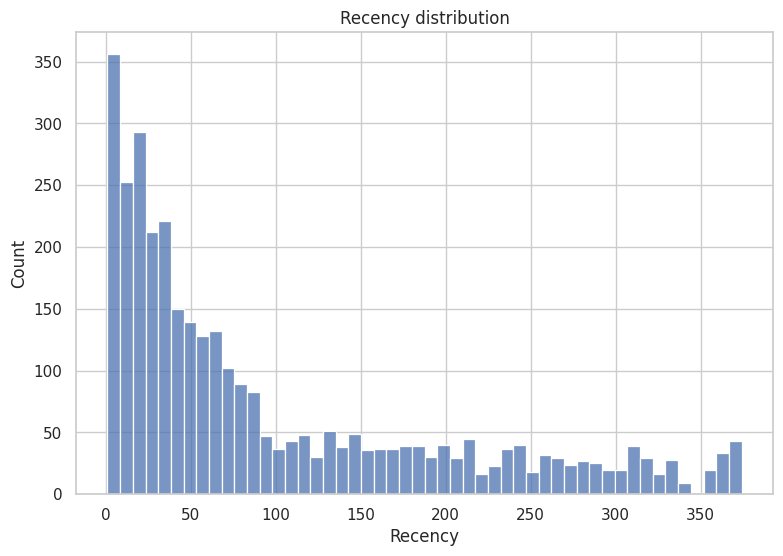

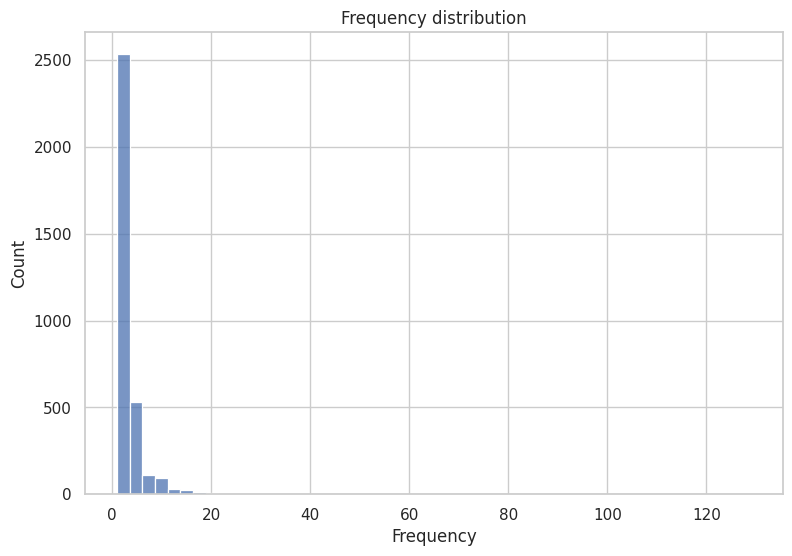

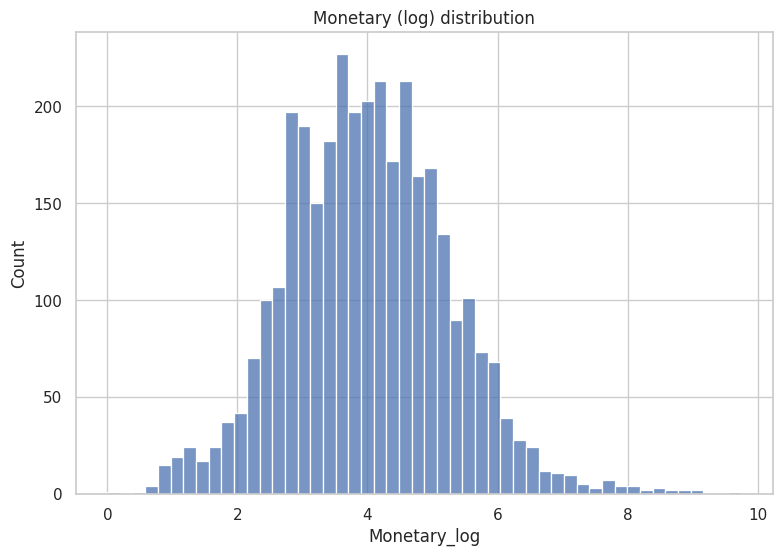

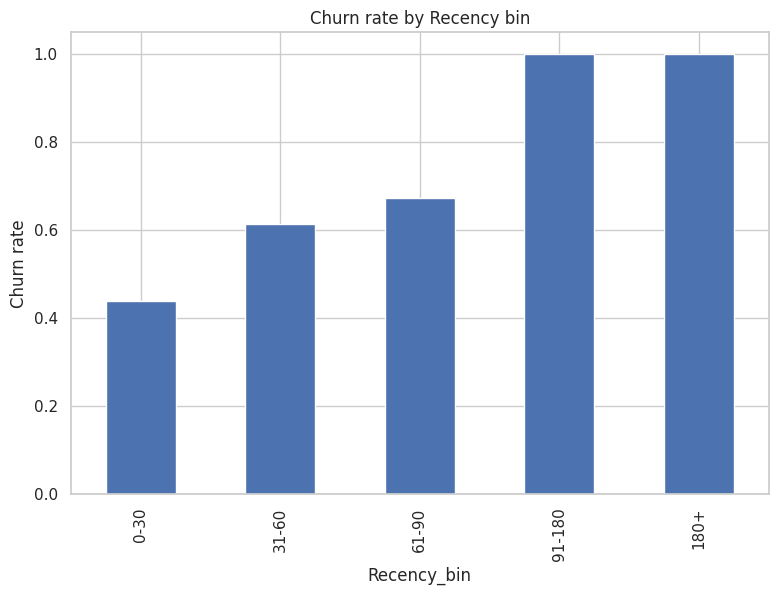

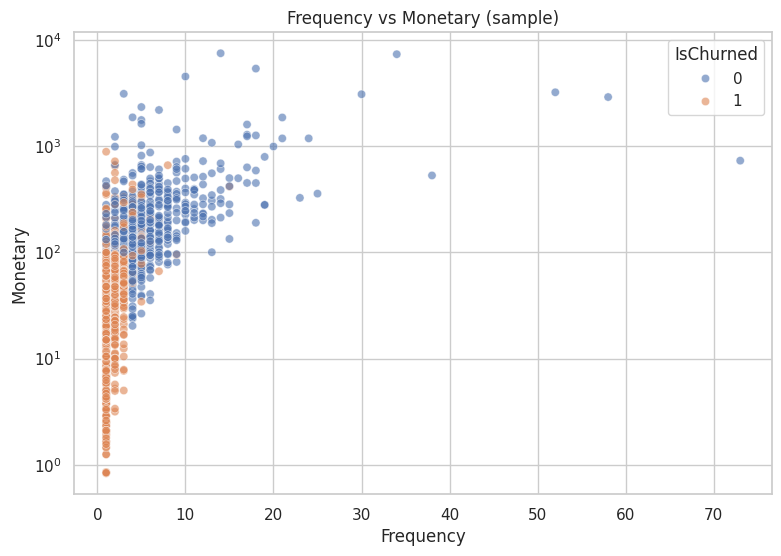

In [ ]:
# Recency, Frequency, Monetary (log)
plt.figure(); sns.histplot(cust['Recency'], bins=50); plt.title('Recency distribution'); plt.show()
plt.figure(); sns.histplot(cust['Frequency'], bins=50); plt.title('Frequency distribution'); plt.show()
plt.figure(); sns.histplot(cust['Monetary_log'], bins=50); plt.title('Monetary (log) distribution'); plt.show()

# Churn rate by Recency bin
cust['Recency_bin'] = pd.cut(cust['Recency'], bins=[-1,30,60,90,180,9999], labels=['0-30','31-60','61-90','91-180','180+'])
churn_by_rec = cust.groupby('Recency_bin')['IsChurned'].mean()
plt.figure(); churn_by_rec.plot(kind='bar'); plt.title('Churn rate by Recency bin'); plt.ylabel('Churn rate'); plt.show()

# RFM scatter (Frequency vs Monetary)
plt.figure(); sns.scatterplot(data=cust.sample(2000, random_state=42), x='Frequency', y='Monetary', hue='IsChurned', alpha=0.6); plt.title('Frequency vs Monetary (sample)'); plt.yscale('log'); plt.show()


In [ ]:
# Chi-square: Recency bin vs IsChurned
cont = pd.crosstab(cust['Recency_bin'], cust['IsChurned'])
chi2, p_chi, dof, ex = chi2_contingency(cont)
# Mann-Whitney: Monetary churn vs not
u_stat, p_u = mannwhitneyu(cust.loc[cust['IsChurned']==1,'Monetary'], cust.loc[cust['IsChurned']==0,'Monetary'], alternative='two-sided')

print(f"Chi2 p-value (Recency_bin vs IsChurned): {p_chi:.4f}")
print(f"Mann-Whitney p-value (Monetary churn vs not): {p_u:.4f}")


Chi2 p-value (Recency_bin vs IsChurned): 0.0000
Mann-Whitney p-value (Monetary churn vs not): 0.0000


In [ ]:
features = ['Recency','Frequency','Monetary_log','AvgOrderValue','DaysSinceFirst']
X = cust[features].fillna(0)

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)

print("PCA 2 components explained variance ratios:", pca2.explained_variance_ratio_.round(3))


PCA 2 components explained variance ratios: [0.571 0.367]


In [ ]:
sil_scores = {}
for k in range(2,9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca3)
    sil_scores[k] = silhouette_score(X_pca3, labels)
print("Silhouette scores by k:", {k: round(v,3) for k,v in sil_scores.items()})

best_k = max(sil_scores, key=sil_scores.get)
print("Best k by silhouette:", best_k)

km = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cust['cluster'] = km.fit_predict(X_pca3)

profile = cust.groupby('cluster')[['Recency','Frequency','Monetary','Monetary_log','AvgOrderValue','DaysSinceFirst']].median().round(2)
profile['count'] = cust.groupby('cluster').size()
profile = profile.sort_values('count', ascending=False)
print("Cluster profile (median + count):")
display(profile)


Silhouette scores by k: {2: np.float64(0.957), 3: np.float64(0.934), 4: np.float64(0.802), 5: np.float64(0.532), 6: np.float64(0.53), 7: np.float64(0.52), 8: np.float64(0.361)}
Best k by silhouette: 2
Cluster profile (median + count):


,Recency,Frequency,Monetary,Monetary_log,AvgOrderValue,DaysSinceFirst,count
cluster,,,,,,,
0,58.0,2.0,52.29,3.98,25.5,233.0,3358
1,23.0,1.5,2681.28,7.88,2139.0,97.5,4


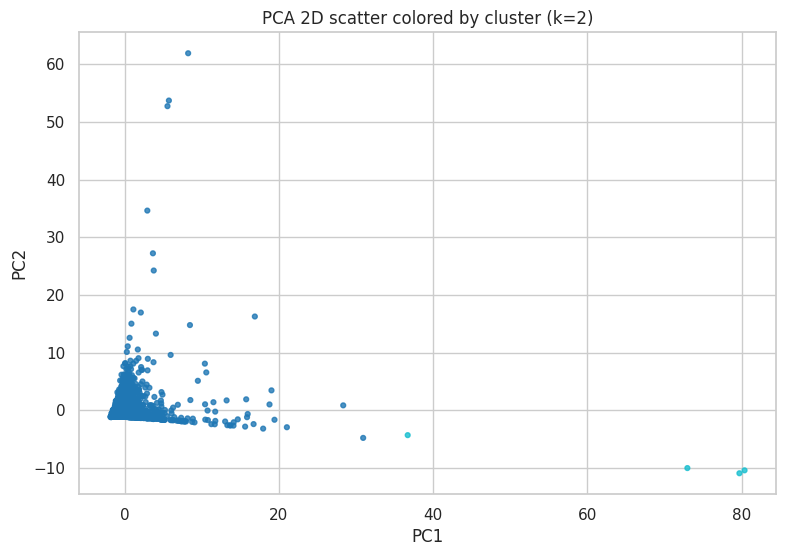

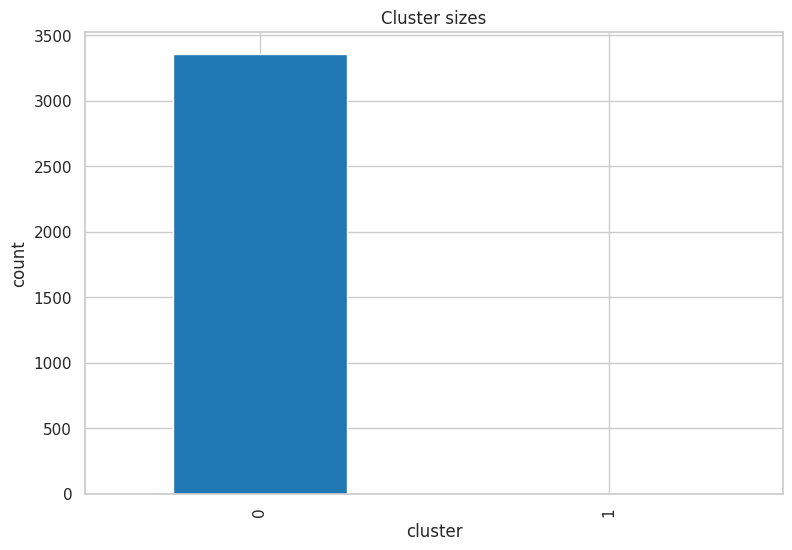

In [ ]:
plt.figure(figsize=(9,6))
palette = sns.color_palette("tab10", n_colors=best_k)
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=cust['cluster'], cmap='tab10', s=12, alpha=0.8)
plt.title(f'PCA 2D scatter colored by cluster (k={best_k})'); plt.xlabel('PC1'); plt.ylabel('PC2'); plt.show()

plt.figure(); cust['cluster'].value_counts().sort_index().plot(kind='bar', color=palette); plt.title('Cluster sizes'); plt.xlabel('cluster'); plt.ylabel('count'); plt.show()


In [ ]:
# Features for classification (use transformed/scaled numeric)
clf_features = ['Recency','Frequency','Monetary_log','AvgOrderValue','DaysSinceFirst','cluster']
X_clf = cust[clf_features].fillna(0)
# One-hot encode cluster
X_clf = pd.get_dummies(X_clf, columns=['cluster'], prefix='cluster')

y = cust['IsChurned']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_clf, y, stratify=y, test_size=0.2, random_state=42)

# Balance training set with SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("Before SMOTE class dist:", y_train.value_counts(normalize=True).to_dict())
print("After SMOTE class dist:", pd.Series(y_train_res).value_counts(normalize=True).to_dict())


Before SMOTE class dist: {1: 0.7010040907400521, 0: 0.29899590925994796}
After SMOTE class dist: {0: 0.5, 1: 0.5}


In [ ]:
dt = DecisionTreeClassifier(random_state=42)
params = {'max_depth':[3,5,8,None], 'min_samples_leaf':[1,5,10]}
gs = GridSearchCV(dt, params, cv=5, scoring='f1', n_jobs=-1)
gs.fit(X_train_res, y_train_res)
best_dt = gs.best_estimator_
print("Best DT params:", gs.best_params_)

y_pred_dt = best_dt.predict(X_test)
y_prob_dt = best_dt.predict_proba(X_test)[:,1]
print("Decision Tree classification report:")
print(classification_report(y_test, y_pred_dt, digits=3))
print("Decision Tree ROC AUC:", roc_auc_score(y_test, y_prob_dt).round(3))


Best DT params: {'max_depth': 5, 'min_samples_leaf': 1}
Decision Tree classification report:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       201
           1      1.000     1.000     1.000       472

    accuracy                          1.000       673
   macro avg      1.000     1.000     1.000       673
weighted avg      1.000     1.000     1.000       673

Decision Tree ROC AUC: 1.0


In [ ]:
# Scale numeric features for NN
ss = StandardScaler()
X_train_nn = ss.fit_transform(X_train_res)
X_test_nn = ss.transform(X_test)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['AUC'])
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train_nn, y_train_res, validation_split=0.15, epochs=100, batch_size=64, callbacks=[es], verbose=1)

y_prob_nn = model.predict(X_test_nn).ravel()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)
print("Neural Network classification report:")
print(classification_report(y_test, y_pred_nn, digits=3))
print("Neural Network ROC AUC:", roc_auc_score(y_test, y_prob_nn).round(3))


Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - AUC: 0.9244 - loss: 0.4800 - val_AUC: 0.0000e+00 - val_loss: 0.4603
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - AUC: 0.9754 - loss: 0.2477 - val_AUC: 0.0000e+00 - val_loss: 0.2314
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - AUC: 0.9818 - loss: 0.1845 - val_AUC: 0.0000e+00 - val_loss: 0.1619
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - AUC: 0.9858 - loss: 0.1592 - val_AUC: 0.0000e+00 - val_loss: 0.1303
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - AUC: 0.9877 - loss: 0.1429 - val_AUC: 0.0000e+00 - val_loss: 0.1331
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - AUC: 0.9886 - loss: 0.1358 - val_AUC: 0.0000e+00 - val_loss: 0.1243
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - AUC: 0.9900 - loss: 0.1316 - val_AUC: 0.0000e+00 - val_loss: 0.1004
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - AUC: 0.9895 - loss: 0.1287 - val_AUC: 0.0000e+00 - val_loss: 0.1114
Epoch 9/100
51/51 ━━━━━━

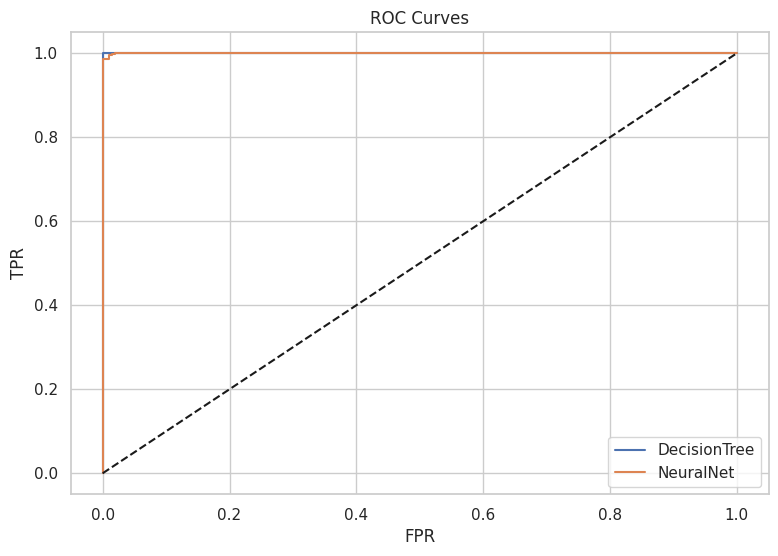

In [ ]:
# ROC curves
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
plt.plot(fpr_dt, tpr_dt, label='DecisionTree')
plt.plot(fpr_nn, tpr_nn, label='NeuralNet')
plt.plot([0,1],[0,1],'k--'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend(); plt.title('ROC Curves'); plt.show()


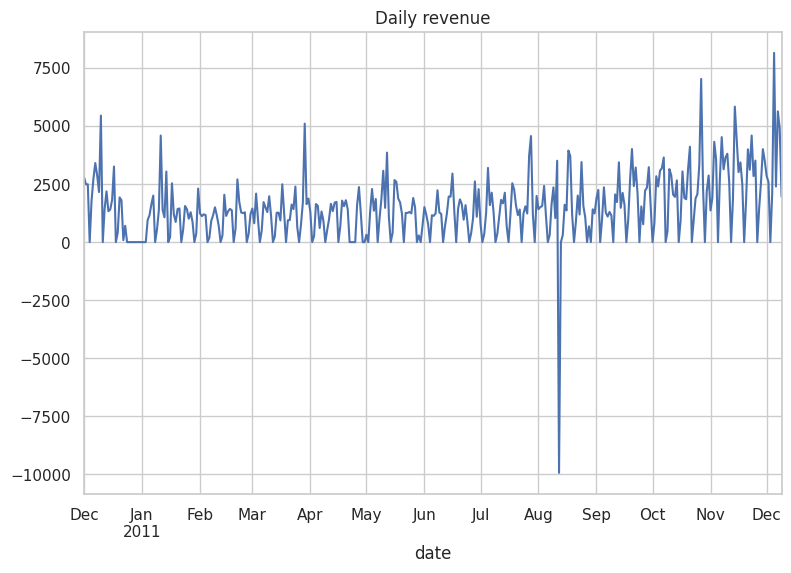

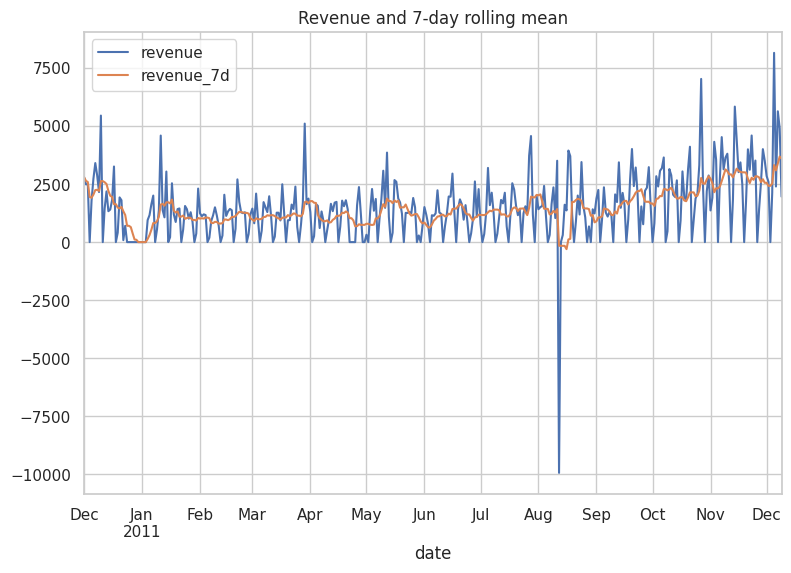

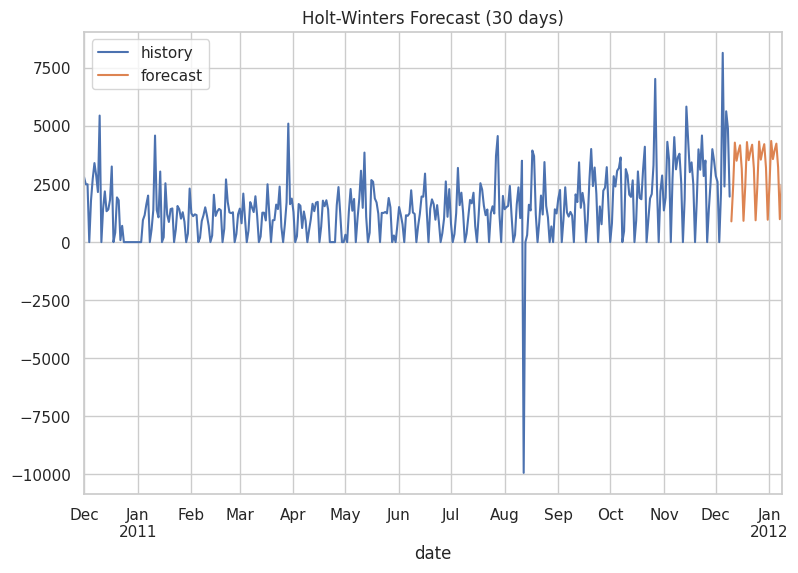

In [ ]:
ts = sample.groupby(sample['InvoiceDate'].dt.date)['TotalPrice'].sum().reset_index()
ts.columns = ['date','revenue']
ts['date'] = pd.to_datetime(ts['date'])
ts = ts.set_index('date').asfreq('D', fill_value=0)

# Plot raw and 7-day rolling
ts['revenue'].plot(title='Daily revenue'); plt.show()
ts['revenue_7d'] = ts['revenue'].rolling(window=7, min_periods=1).mean()
ts[['revenue','revenue_7d']].plot(title='Revenue and 7-day rolling mean'); plt.show()

# Holt-Winters forecast (7-day seasonality)
from statsmodels.tsa.holtwinters import ExponentialSmoothing
model_hw = ExponentialSmoothing(ts['revenue'], trend='add', seasonal='add', seasonal_periods=7)
hw_fit = model_hw.fit(optimized=True)
forecast = hw_fit.forecast(30)
plt.figure(); ts['revenue'].plot(label='history'); forecast.plot(label='forecast'); plt.legend(); plt.title('Holt-Winters Forecast (30 days)'); plt.show()


In [ ]:
cust.to_csv('online_retail_customers_processed.csv', index=False)
print("Saved customer-level file: online_retail_customers_processed.csv")


Saved customer-level file: online_retail_customers_processed.csv
